# Hi-C basics — `pairs → .cool → balanced → heatmap`

This tutorial exercises the `epione.hic` scaffold end-to-end on a
**synthetic** contact matrix, so the pipeline runs without any real
Hi-C data download. The data generator writes a 4DN-compatible
`.pairs` file whose contacts decay with distance along a power-law,
which is enough to drive the ICE balance step to a sensible weight
vector and produce a legible off-diagonal-decay heatmap.

For a real biological walkthrough (compartments / TADs / loops on
Drosophila Hi-C), see `t_hic_analysis.ipynb` (Phase 2, coming next).

### What this exercises

| Step | epione call |
| --- | --- |
| pairs.gz → .cool   | `epi.hic.pairs_to_cool` (wraps `cooler cload pairs`) |
| .cool → balanced   | `epi.hic.balance_cool` (ICE via `cooler.balance_cooler`) |
| region heatmap     | `epi.hic.plot_contact_matrix` |

## 1 · Setup + synthetic pairs generator

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysam
import cooler

import epione as epi
epi.pl.plot_set()

OUT = pathlib.Path('result') / 't_hic_basics'
OUT.mkdir(parents=True, exist_ok=True)

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



In [2]:
def make_synthetic_pairs(out_dir: pathlib.Path,
                          n_pairs: int = 50_000,
                          chrom: str = 'chr_synt',
                          size: int = 5_000_000,
                          seed: int = 0) -> tuple[pathlib.Path, pathlib.Path]:
    '''Write a 4DN `.pairs.gz` with power-law decaying intra-chrom contacts.'''
    rng = np.random.default_rng(seed)
    sizes = out_dir / 'chrom.sizes'
    sizes.write_text(f'{chrom}\t{size}\n')

    d    = rng.exponential(30_000, n_pairs).astype(int)
    pos1 = rng.integers(0, size - d.max() - 1, n_pairs)
    pos2 = pos1 + d
    mask = pos2 < size
    pos1, pos2 = pos1[mask], pos2[mask]

    pairs = out_dir / 'synt.pairs'
    with pairs.open('w') as fh:
        fh.write('## pairs format v1.0\n')
        fh.write(f'#chromsize: {chrom} {size}\n')
        fh.write('#columns: readID chrom1 pos1 chrom2 pos2 strand1 strand2\n')
        for i, (p1, p2) in enumerate(zip(pos1, pos2)):
            fh.write(f'r{i}\t{chrom}\t{p1}\t{chrom}\t{p2}\t+\t+\n')
    pairs_gz = out_dir / 'synt.pairs.gz'
    pysam.tabix_compress(str(pairs), str(pairs_gz), force=True)
    pairs.unlink()
    return pairs_gz, sizes

pairs_gz, chrom_sizes = make_synthetic_pairs(OUT)
print(f'pairs  → {pairs_gz}  ({pairs_gz.stat().st_size/1024:.1f} KB)')
print(f'sizes  → {chrom_sizes}  ({chrom_sizes.read_text().strip()})')

pairs  → result/t_hic_basics/synt.pairs.gz  (507.9 KB)
sizes  → result/t_hic_basics/chrom.sizes  (chr_synt	5000000)


## 2 · `pairs → .cool`

`epi.hic.pairs_to_cool` streams the pairs file into a binned contact
matrix via `cooler cload pairs`. A 50-kb resolution on a 5-Mb
chromosome gives 100 bins per side — small enough to display cleanly
and big enough that power-law decay is visible.

In [3]:
cool_path = OUT / 'synt.cool'
epi.hic.pairs_to_cool(
    pairs_path=pairs_gz,
    chrom_sizes=chrom_sizes,
    out_cool=cool_path,
    binsize=50_000,
)

c = cooler.Cooler(str(cool_path))
print(f'bins    : {len(c.bins()[:])}')
print(f'pixels  : {int(c.pixels()[:].shape[0]):,}')
print(f'chromsize: {dict(c.chromsizes)}')

INFO:cooler.create:Writing chunk 0: /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/result/t_hic_basics/tmp4gtupcpt.multi.cool::0


bins    : 100
pixels  : 478
chromsize: {'chr_synt': np.int32(5000000)}


INFO:cooler.create:Creating cooler at "/scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/result/t_hic_basics/tmp4gtupcpt.multi.cool::/0"
INFO:cooler.create:Writing chroms
INFO:cooler.create:Writing bins
INFO:cooler.create:Writing pixels
INFO:cooler.create:Writing indexes
INFO:cooler.create:Writing info
INFO:cooler.create:Merging into result/t_hic_basics/synt.cool
INFO:cooler.create:Creating cooler at "/scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/result/t_hic_basics/synt.cool::/"
INFO:cooler.create:Writing chroms
INFO:cooler.create:Writing bins
INFO:cooler.create:Writing pixels
INFO:cooler._reduce:n_merge_epochs: 1
INFO:cooler._reduce:nnzs: [478]
INFO:cooler._reduce:records consumed: [np.int64(478)]
INFO:cooler.create:Writing indexes
INFO:cooler.create:Writing info


## 3 · ICE balance

`balance_cool` runs cooler's iterative correction in place and writes
the `bins/weight` column. The returned dict exposes whether it
converged, how many bins got masked for low coverage, and the
rescaling scale.

In [4]:
stats = epi.hic.balance_cool(
    cool_path,
    mad_max=10, min_nnz=1, min_count=0,
    ignore_diags=0, max_iters=500, tol=1e-5,
)
stats

{'converged': False,
 'n_iters': 0,
 'n_masked': 8,
 'scale': 1131.5978928870607,
 'var': 43.38281991861097,
 'reused_existing': False}

## 4 · Pre- vs post-balance heatmap

Render the same chromosome twice: raw counts first, then the
balanced matrix (which divides each cell by the outer product of its
two bin weights).

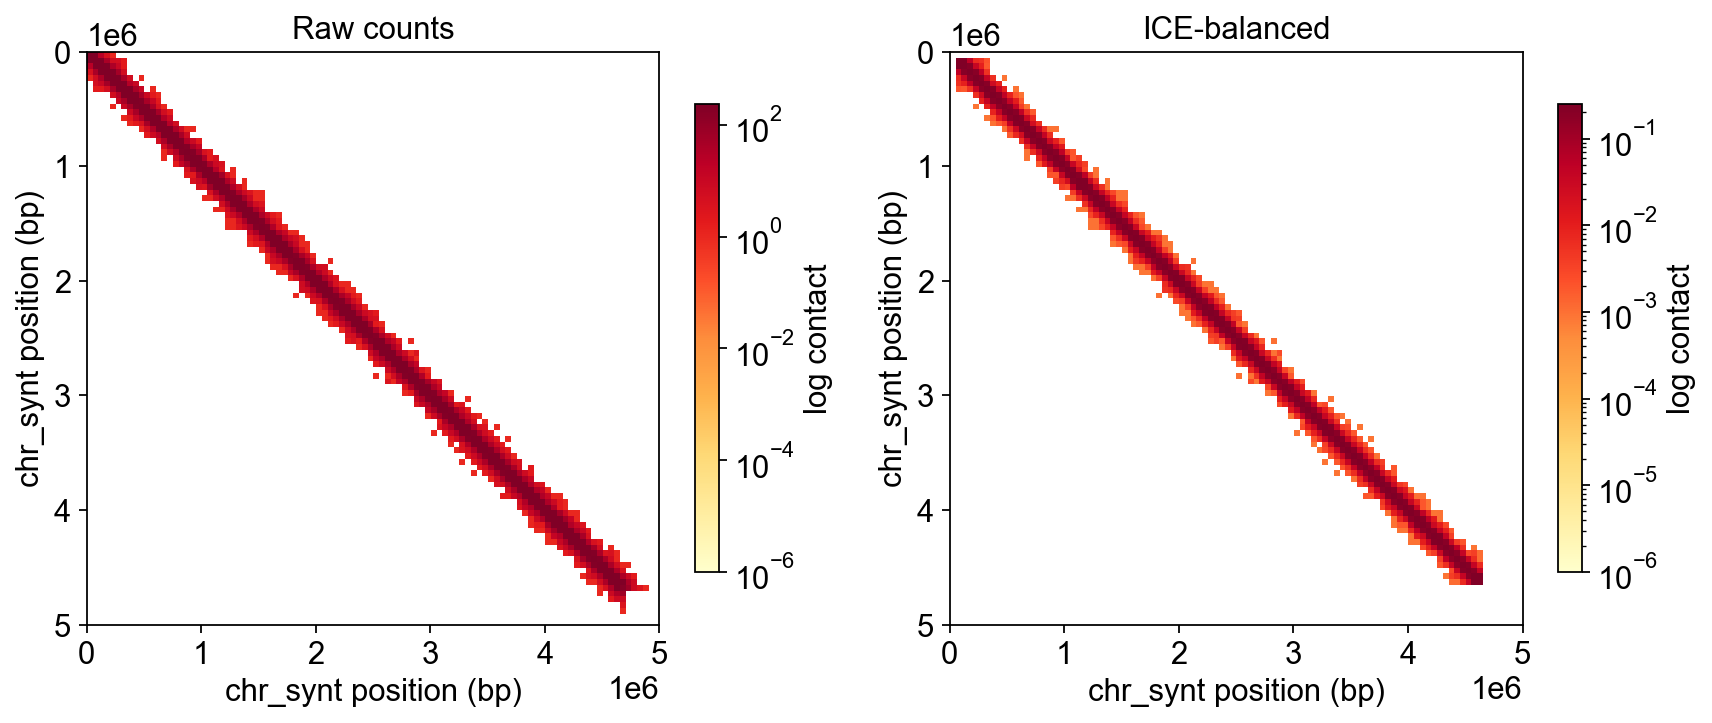

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

epi.hic.plot_contact_matrix(
    cool_path, region='chr_synt',
    balance=False, log=True,
    ax=axes[0], title='Raw counts',
)
epi.hic.plot_contact_matrix(
    cool_path, region='chr_synt',
    balance=True, log=True,
    ax=axes[1], title='ICE-balanced',
)
plt.tight_layout()
plt.show()

The classic Hi-C signature is visible in both panels — contact
frequency decays as a function of distance from the diagonal. ICE
balancing flattens the marginal coverage without altering that shape.

### Next

The Phase 2 tutorial (`t_hic_analysis.ipynb`) swaps the synthetic
matrix for the Galaxy HiCExplorer Drosophila dataset and adds:

- A / B compartments via `hicPCA`-equivalent eigendecomposition;
- TAD boundaries via insulation score;
- Loop peak calling via dot-finder;
- A composite *"Hi-C triangle + TAD boundaries + ATAC/ChIP tracks"*
  plot plugged into `epi.bulk.bigwig.plot_track_multi`.